In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_tk.lists_sessions as lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplenet.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Threshold:", sorted(df["Threshold"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 1092 rows from spikes\all_networks_metrics_ripplenet.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Threshold: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed123,78,178,31,0.304688,0.715596,0.427397,35.347436,269,109
1,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed456,78,158,31,0.330508,0.715596,0.452174,34.717949,244,109
2,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed789,77,189,32,0.289474,0.706422,0.410667,30.353680,277,109
3,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_random_seed123,66,99,43,0.400000,0.605505,0.481752,40.259091,171,109
4,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_random_seed456,80,180,29,0.307692,0.733945,0.433604,32.437917,271,109


In [5]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions
df = df[~df["Session"].isin(hfo_sessions)]



# og_session_set={"2025-09-22_17-55-26", #R
#                 "2025-09-23_15-50-26", #R
#                 "2025-09-24_10-24-40", #R
#                 "2025-09-24_14-22-55", #H
#                 "2025-09-24_15-13-10", #H
#                 "2025-09-25_16-41-14"} #R
# df=df[df["Session"].isin(og_session_set)]

# # New sessions:
# session_set={"2025-09-24_16-29-07", #R   
#         "2025-09-24_17-38-17",
#         "2025-09-25_12-52-22",
#         "2025-09-24_11-34-51",
#         } #R 
# df=df[~df["Session"].isin(session_set)]
print(df["Session"].unique())
# df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-22_17-42-27' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-23_16-17-52' '2025-09-24_10-24-40' '2025-09-24_11-34-51'
 '2025-09-24_16-29-07' '2025-09-24_17-38-17' '2025-09-25_11-21-53'
 '2025-09-25_12-52-22' '2025-09-25_16-41-14']


In [11]:
# Print summary
print("\n--- Summary by Network ---")
summary = df.groupby("Threshold")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Network ---


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.7,0.473,0.501,0.641,40.0,42.0,44.5
0.6,0.462,0.449,0.722,45.0,57.5,36.5
0.4,0.445,0.362,0.806,53.0,133.0,24.0
0.3,0.435,0.332,0.892,58.5,183.5,17.0
0.5,0.434,0.398,0.772,49.0,96.5,29.0
0.8,0.402,0.599,0.529,35.0,28.0,55.0
0.9,0.333,0.681,0.333,26.5,12.0,68.0


In [16]:
# Print summary
print("\n--- Summary by Network ---")
for model in df["Model"].unique():
    print(f"\nModel: {model}")
    model_df = df[df["Model"] == model]
    model_summary = model_df.groupby("Threshold")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
    display(model_summary)



--- Summary by Network ---

Model: ripplenet_bidirectional_best_random_seed123


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.8,0.524,0.582,0.604,46.0,81.0,43.0
0.7,0.519,0.523,0.681,56.0,115.0,33.0
0.6,0.512,0.448,0.729,62.0,156.0,30.0
0.5,0.477,0.374,0.837,65.0,198.0,27.0
0.9,0.472,0.652,0.472,34.0,40.0,58.0
0.4,0.465,0.338,0.871,68.0,237.0,23.0
0.3,0.427,0.305,0.908,69.0,274.0,16.0



Model: ripplenet_bidirectional_best_random_seed456


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.7,0.557,0.500,0.738,55.0,80.0,37.0
0.9,0.525,0.721,0.524,37.0,34.0,55.0
0.8,0.519,0.597,0.597,47.0,50.0,42.0
0.6,0.516,0.424,0.784,63.0,111.0,29.0
0.5,0.495,0.373,0.843,65.0,156.0,27.0
0.4,0.462,0.333,0.876,68.0,206.0,23.0
0.3,0.436,0.308,0.901,72.0,257.0,17.0



Model: ripplenet_bidirectional_best_random_seed789


...

,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.3,0.500,0.462,0.892,47.0,116.0,20.0
0.4,0.496,0.610,0.806,47.0,63.0,27.0
0.7,0.417,0.800,0.432,29.0,7.0,71.0
0.6,0.365,0.805,0.590,34.0,16.0,59.0
0.5,0.333,0.710,0.719,44.0,33.0,42.0
0.8,0.286,0.900,0.259,24.0,1.0,71.0
0.9,0.206,0.900,0.133,16.0,0.0,90.0



Model: ripplenet_unidirectional_random_seed456


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.3,0.504,0.521,0.835,47.0,88.0,23.0
0.5,0.434,0.738,0.561,33.0,19.0,61.0
0.4,0.413,0.673,0.719,45.0,37.0,48.0
0.6,0.410,0.806,0.403,29.0,5.0,71.0
0.7,0.370,0.833,0.259,24.0,2.0,71.0
0.8,0.229,0.875,0.188,18.0,1.0,89.0
0.9,0.134,1.000,0.072,10.0,0.0,91.0



Model: ripplenet_unidirectional_random_seed789


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.6,0.492,0.840,0.410,30.0,7.0,71.0
0.3,0.446,0.500,0.835,46.0,65.0,27.0
0.5,0.395,0.786,0.561,37.0,15.0,61.0
0.4,0.371,0.667,0.691,44.0,27.0,54.0
0.7,0.345,0.818,0.317,27.0,3.0,71.0
0.8,0.286,0.979,0.187,17.0,0.0,90.0
0.9,0.118,0.976,0.067,8.0,0.0,91.0


In [17]:
# Print summary
print("\n--- Summary by Network ---")
summary = df.groupby(["Threshold"])[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Network ---


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.7,0.473,0.501,0.641,40.0,42.0,44.5
0.6,0.462,0.449,0.722,45.0,57.5,36.5
0.4,0.445,0.362,0.806,53.0,133.0,24.0
0.3,0.435,0.332,0.892,58.5,183.5,17.0
0.5,0.434,0.398,0.772,49.0,96.5,29.0
0.8,0.402,0.599,0.529,35.0,28.0,55.0
0.9,0.333,0.681,0.333,26.5,12.0,68.0


In [18]:
print(summary.loc[summary["F1"].idxmax()])

F1            0.473
Precision     0.501
Recall        0.641
TP           40.000
FP           42.000
FN           44.500
Name: 0.7, dtype: float64


In [19]:
# Print summary
print("\n--- Summary by Session ---")
summary = df.groupby("Session")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Session ---


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-23_15-50-26,0.625,0.710,0.698,97.036,64.631,41.964
2025-09-22_17-55-26,0.574,0.618,0.688,127.286,137.976,57.714
2025-09-25_16-41-14,0.496,0.587,0.574,82.702,102.929,61.298
2025-09-25_11-21-53,0.464,0.396,0.777,156.940,451.952,45.060
2025-09-22_17-42-27,0.419,0.625,0.424,46.262,53.452,62.738
2025-09-24_10-24-40,0.418,0.714,0.417,38.357,31.071,53.643
2025-09-23_16-17-52,0.408,0.608,0.441,31.786,34.750,40.214
2025-09-24_16-29-07,0.336,0.286,0.828,33.119,190.024,6.881
2025-09-24_11-34-51,0.216,0.380,0.180,12.798,16.548,58.202


In [20]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

N=11 matched samples for statistics.
0.6 vs 0.9: p=0.0420
0.7 vs 0.9: p=0.0098
0.8 vs 0.9: p=0.0068


C:\Users\Pc\AppData\Local\Temp\ipykernel_28812\79562911.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)


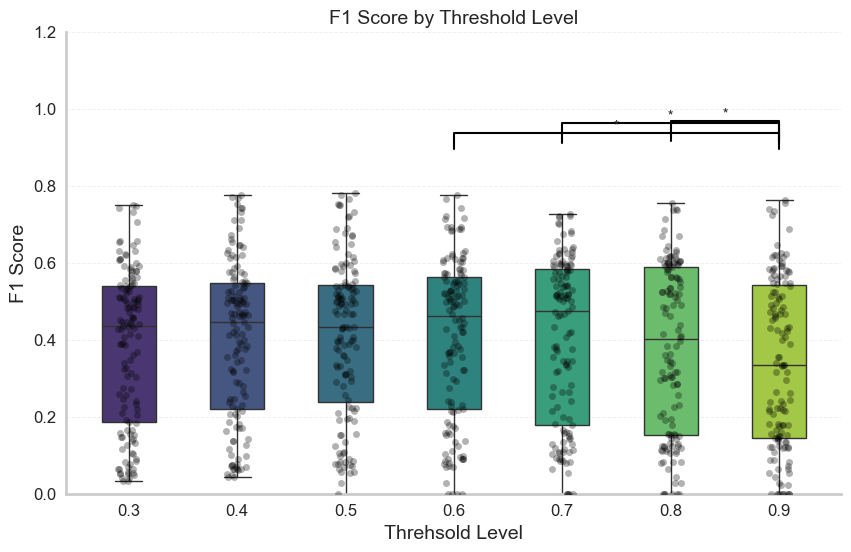

In [21]:
def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Threshold"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Boxplot
    sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
    
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_title(f"{metric} Score by Threshold Level{title_suffix}",fontsize=14)
    ax.set_ylim(0, 1.2) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threhsold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()

if 'df' in locals():
    plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_network=False)

C:\Users\Pc\AppData\Local\Temp\ipykernel_28812\3083535743.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
C:\Users\Pc\AppData\Local\Temp\ipykernel_28812\3083535743.py:23: UserWarning: 
The palette list has fewer values (4) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)


0.3 vs 0.4: p=0.1748
0.3 vs 0.5: p=0.2783
0.3 vs 0.6: p=0.4648
0.3 vs 0.7: p=0.7646
0.3 vs 0.8: p=0.8984
0.3 vs 0.9: p=0.5771
0.4 vs 0.5: p=0.5195
0.4 vs 0.6: p=0.7646
0.4 vs 0.7: p=0.9658
0.4 vs 0.8: p=0.6377
0.4 vs 0.9: p=0.3652
0.5 vs 0.6: p=1.0000
0.5 vs 0.7: p=0.8311
0.5 vs 0.8: p=0.4648
0.5 vs 0.9: p=0.1230
0.6 vs 0.7: p=0.4648
0.6 vs 0.8: p=0.2783
0.6 vs 0.9: p=0.0420
0.7 vs 0.8: p=0.0674
0.7 vs 0.9: p=0.0098
0.8 vs 0.9: p=0.0068


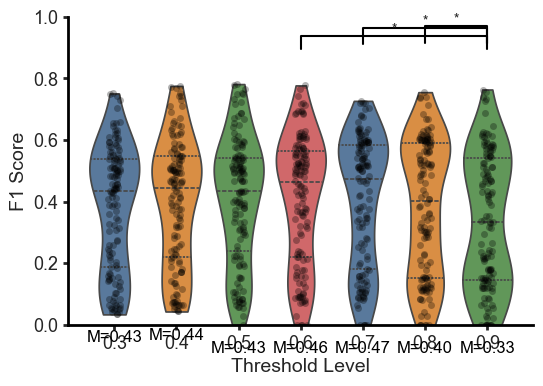

In [22]:
def plot_f1_violin_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())

    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(6, 4))
    
    colors=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

    # Violin plot
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    # display(pivot.head())
    pivot = pivot.dropna()

    # Annotate medians and N
    medians = plot_df.groupby('Threshold')[metric].median()
    counts = plot_df.groupby('Threshold')[metric].count()
    mins=plot_df.groupby('Threshold')[metric].min() 
        
    for i, adapt in enumerate(adapt_values):
        if adapt in medians:
            val = medians[adapt]
            min_val = mins[adapt]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3: 
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                print(f"{a1} vs {a2}: p={p:.4f}")
                barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
                
    # ax.set_title(f"{metric} Distribution by Adaptation Level{title_suffix}")
    ax.set_ylim(0,1) 

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.3)
    ax.spines[['bottom','left']].set_color('black')
    # ax.set_xticklabels(["Fixed","60", "10", "1"])
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2)
    ax.tick_params(axis='x', rotation=0)

    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threshold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()
    return fig,ax

if 'df' in locals():
    fig,ax=plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    os.makedirs("figures", exist_ok=True)
    # fig.savefig("figures/f1_violin_by_adapt.svg", dpi=300, bbox_inches='tight')
    # fig.savefig("figures/f1_violin_by_adapt.png",dpi=300)

C:\Users\Pc\AppData\Local\Temp\ipykernel_28812\1127962853.py:28: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


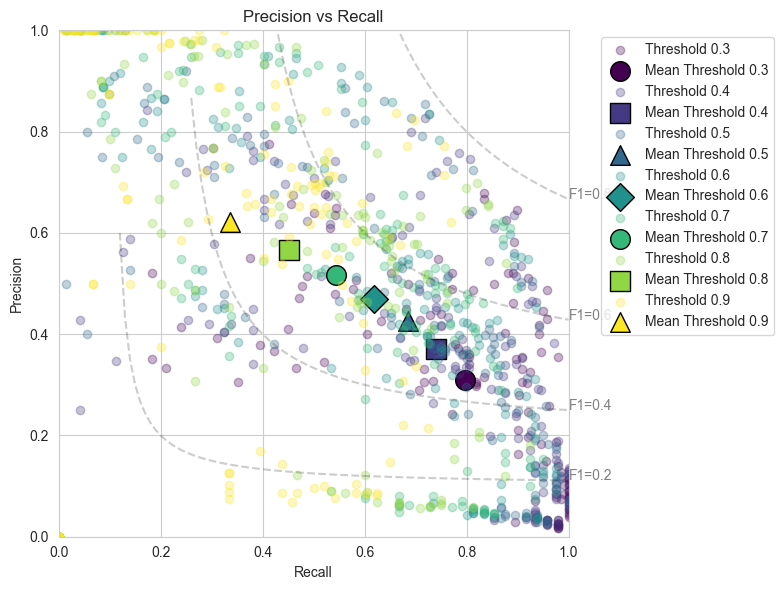

In [23]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
    #  # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Threshold"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Threshold {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Threshold {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if 'df' in locals():
    plot_precision_recall(df)

C:\Users\Pc\AppData\Local\Temp\ipykernel_28812\1415075225.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Threshold", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)


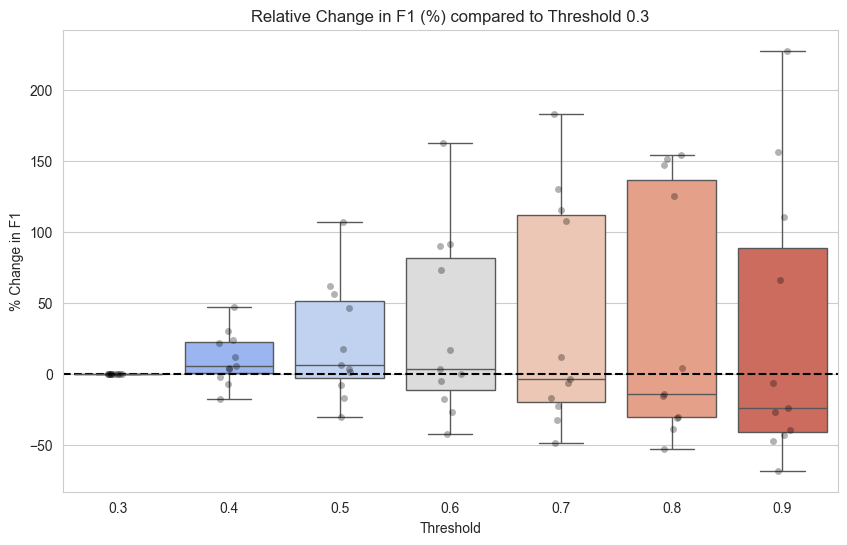

In [27]:
def plot_relative_change(df, metric="F1"):
    # Pivot to have Adapt as columns
    pivot_cols = ["Session", "Channel",]
    if "Dataset" in df.columns:
        pivot_cols.append("Dataset")
        
    pivot = df.pivot_table(index=pivot_cols, columns="Threshold", values=metric) # Pivot table
    # print(pivot.head())
    # Calculate change relative to Adapt 0 (or lowest adapt value)
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values= sorted(df["Threshold"].unique())
    baseline_adapt = 0.3
    
    if baseline_adapt not in pivot.columns:
        print(f"Baseline adapt {baseline_adapt} not found in pivot columns.")
        return

    changes = pd.DataFrame()
    for col in pivot.columns:
        changes[col] = (pivot[col] - pivot[baseline_adapt]) / pivot[baseline_adapt] * 100
        
    # Melt for plotting
    melted = changes.melt(var_name="Threshold", value_name="Percent Change")
    # print(melted)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Threshold", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y="Percent Change", data=melted, color="black", alpha=0.3, jitter=True, order=adapt_values)

    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Relative Change in {metric} (%) compared to Threshold {baseline_adapt}")
    plt.ylabel(f"% Change in {metric}")
    plt.show()

if 'df' in locals():
    plot_relative_change(df, "F1")

,Session,Channel,Threshold,Metric,Value
0,2025-09-22_17-42-27,24,0.3,Precision,0.304688
1,2025-09-22_17-42-27,24,0.3,Precision,0.330508
2,2025-09-22_17-42-27,24,0.3,Precision,0.289474
3,2025-09-22_17-42-27,24,0.3,Precision,0.400000
4,2025-09-22_17-42-27,24,0.3,Precision,0.307692


C:\Users\Pc\AppData\Local\Temp\ipykernel_28812\2978468147.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)


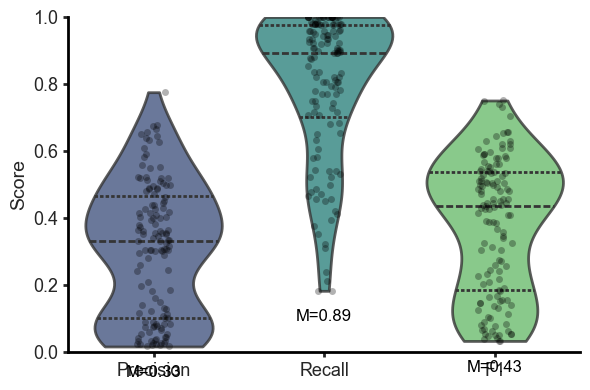

In [26]:
# Plot Precision, Recall and F1 for a single Adaptation level in the same figure
def plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False, metrics=("Precision", "Recall", "F1")):
    """Plot the distributions of multiple metrics for a single `adapt` value in one plot."""
    # Ensure adapt exists in the dataframe
    if adapt not in df["Threshold"].unique():
        print(f"Adapt {adapt} not present in dataframe. Available: {sorted(df['Threshold'].unique())}")
        return

    # Prepare data for the requested adapt
    if aggregate_by_network:
        agg_cols = ['Network', 'Adapt']
        plot_df = df.groupby(agg_cols)[list(metrics)].mean().reset_index()
        title_suffix = ' (Averaged by Network)'
    else:
        plot_df = df.copy()
        title_suffix = ''

    plot_df = plot_df[plot_df['Threshold'] == adapt]
    if len(plot_df) == 0:
        print(f'No rows for Threshold {adapt} after filtering.')
        return

    # Melt metrics into long form for plotting
    id_vars = [c for c in ['Session', 'Channel', 'Threshold'] if c in plot_df.columns]
    melted = plot_df.melt(id_vars=id_vars, value_vars=list(metrics), var_name='Metric', value_name='Value')
    display(melted.head())
    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    order = list(metrics)
    sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)
    sns.stripplot(x='Metric', y='Value', data=melted, ax=ax, color='k', alpha=0.3, jitter=True, order=order)

    # Annotate medians and N
    medians = melted.groupby('Metric')['Value'].median()
    counts = melted.groupby('Metric')['Value'].count()
    mins=melted.groupby('Metric')['Value'].min() 
    
    for i, metric in enumerate(order):
        if metric in medians:
            val = medians[metric]
            min_val = mins[metric]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    ax.set_ylim(0, 1)
    # ax.set_title(f'Performance Metrics', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_xlabel('')
    # ax.set_xlabel('Metric', fontsize=14)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')

    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)
    # ax.set_yticks(np.arange(0.3, 1.1, 0.1))
    plt.tight_layout()
    plt.show()
    return fig, ax

if 'df' in locals():
    fig,ax=plot_metrics_single_adapt(df, adapt=0.3, aggregate_by_network=False)
    # plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    # fig.savefig("figures/metrics_single_adapt.svg", format="svg")
    # fig.savefig("figures/metrics_single_adapt.png", format="png", dpi=300)